In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.pyplot import title
from scipy import stats # Import scipy.stats for t-distribution
import os
import matplotlib as mpl # Import matplotlib separately for rcParams

In [25]:
# preparing dataframes for the plots with confidence interval
dfs = []

rounds_batch_size_dict = {
    34: 24,
    39: 21,
    45: 18,
    54: 15,
    67: 12,
    89: 9,
    134: 6,
    267:3
}

In [26]:
model_size_bytes = 2.65 # Tamanho do modelo em megabytes
num_clients = 10  # Número de clientes

# Calcula os bytes transmitidos por rodada
bytes_transmitted_per_round = model_size_bytes * num_clients

for key, value in rounds_batch_size_dict.items():
    path = f"results/federated_kfold_size_2000_clients_10_rounds_{key}_batch_{value}_kfold_5_metrics.csv"
    print(f"Loading {path}")
    df = pd.read_csv(path)
    df['total_bytes_transmitted'] = df['round'] * bytes_transmitted_per_round
    print(f"Done loading {path}")
    dfs.append(df)
df_avg = pd.read_csv("./results/cross_validation/federated_cv_results.csv")
df_centralized = pd.read_csv("cv_metrics_batch_size_32_avg.csv")

Loading results/federated_kfold_size_2000_clients_10_rounds_34_batch_24_kfold_5_metrics.csv
Done loading results/federated_kfold_size_2000_clients_10_rounds_34_batch_24_kfold_5_metrics.csv
Loading results/federated_kfold_size_2000_clients_10_rounds_39_batch_21_kfold_5_metrics.csv
Done loading results/federated_kfold_size_2000_clients_10_rounds_39_batch_21_kfold_5_metrics.csv
Loading results/federated_kfold_size_2000_clients_10_rounds_45_batch_18_kfold_5_metrics.csv
Done loading results/federated_kfold_size_2000_clients_10_rounds_45_batch_18_kfold_5_metrics.csv
Loading results/federated_kfold_size_2000_clients_10_rounds_54_batch_15_kfold_5_metrics.csv
Done loading results/federated_kfold_size_2000_clients_10_rounds_54_batch_15_kfold_5_metrics.csv
Loading results/federated_kfold_size_2000_clients_10_rounds_67_batch_12_kfold_5_metrics.csv
Done loading results/federated_kfold_size_2000_clients_10_rounds_67_batch_12_kfold_5_metrics.csv
Loading results/federated_kfold_size_2000_clients_10_ro

In [27]:
print(dfs[1].columns)
print(df_centralized.columns)
print(df_avg.columns)

Index(['round', 'total_samples_processed', 'accuracy', 'accuracy_std', 'loss',
       'loss_std', 'total_bytes_transmitted'],
      dtype='object')
Index(['round', 'total_samples_processed', 'accuracy', 'accuracy_std', 'loss',
       'loss_std', 'total_bytes_transmitted'],
      dtype='object')
Index(['communication_round', 'loss', 'accuracy', 'images_seen_this_round',
       'total_images_seen', 'std_loss', 'std_accuracy'],
      dtype='object')


In [28]:
df_avg.rename(
    columns={"communication_round": "round",
             "total_images_seen": "total_samples_processed",
             "std_loss": "loss_std",
             "std_accuracy": "accuracy_std",},
    inplace=True
)

df_avg.columns

Index(['round', 'loss', 'accuracy', 'images_seen_this_round',
       'total_samples_processed', 'loss_std', 'accuracy_std'],
      dtype='object')

In [29]:
df_avg

,round,loss,accuracy,images_seen_this_round,total_samples_processed,loss_std,accuracy_std
0,1,2.105794,0.4840,1590.0,1590.0,0.021690,0.082246
1,2,1.898863,0.6700,1590.0,3180.0,0.039587,0.040889
2,3,1.681757,0.7330,1590.0,4770.0,0.056723,0.028251
3,4,1.477703,0.7470,1590.0,6360.0,0.071120,0.034839
4,5,1.293561,0.7680,1590.0,7950.0,0.082971,0.040866
5,6,1.132455,0.7850,1590.0,9540.0,0.091128,0.036185
6,7,0.993685,0.8000,1590.0,11130.0,0.093649,0.034233
7,8,0.876467,0.8115,1590.0,12720.0,0.093630,0.027249
8,9,0.780343,0.8205,1590.0,14310.0,0.092433,0.029176
9,10,0.702079,0.8275,1590.0,15900.0,0.090355,0.028668


In [30]:
dfs[0]

,round,total_samples_processed,accuracy,accuracy_std,loss,loss_std,total_bytes_transmitted
0,1,240.0,0.3725,0.096258,2.112312,0.019834,26.5
1,2,480.0,0.5695,0.053074,1.912759,0.024001,53.0
2,3,720.0,0.7005,0.035637,1.716645,0.032588,79.5
3,4,960.0,0.7240,0.008768,1.538775,0.039214,106.0
4,5,1200.0,0.7460,0.023359,1.380348,0.038896,132.5
5,6,1440.0,0.7545,0.042990,1.234596,0.046712,159.0
6,7,1680.0,0.7605,0.045187,1.107124,0.053440,185.5
7,8,1920.0,0.7650,0.037956,1.000045,0.060058,212.0
8,9,2160.0,0.7845,0.038625,0.896403,0.064043,238.5
9,10,2400.0,0.8010,0.029717,0.807354,0.063753,265.0


In [31]:
df_centralized

,round,total_samples_processed,accuracy,accuracy_std,loss,loss_std,total_bytes_transmitted
0,32.0,32.0,0.08125,0.064348,2.305895,0.011983,501760
1,64.0,64.0,0.18125,0.077560,2.218971,0.042754,501760
2,96.0,96.0,0.27500,0.060596,2.071709,0.050766,501760
3,128.0,128.0,0.28750,0.057282,2.070729,0.088906,501760
4,160.0,160.0,0.49375,0.091430,1.969129,0.065361,501760
...,...,...,...,...,...,...,...
495,15872.0,15872.0,1.00000,0.000000,0.011442,0.004528,501760
496,15904.0,15904.0,1.00000,0.000000,0.014192,0.006332,501760
497,15936.0,15936.0,1.00000,0.000000,0.009053,0.003215,501760
498,15968.0,15968.0,1.00000,0.000000,0.006908,0.006287,501760


In [6]:
width_pt = 504  # replace with your \textwidth in pt
inches_per_pt = 1.0 / 72.27
fig_width = width_pt * inches_per_pt  # width in inches
fig_height = fig_width * 0.618  # golden ratio
print(f"fig_width: {fig_width}")
print(f"fig_height: {fig_height}")

fig_width: 6.973848069738481
fig_height: 4.309838107098381


In [7]:
# --- Configure matplotlib style and fonts ---
# Create directory if it doesn't exist
os.makedirs('images', exist_ok=True)

# Configure matplotlib to use LaTeX fonts and match sbrt style
mpl.rcParams["text.usetex"] = True # Requires LateX
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["font.size"] = 16
mpl.rcParams["axes.labelsize"] = 16
mpl.rcParams["axes.titlesize"] = 16
mpl.rcParams["xtick.labelsize"] = 16
mpl.rcParams["ytick.labelsize"] = 16
mpl.rcParams["legend.fontsize"] = 16
mpl.rcParams["figure.titlesize"] = 16

# Use the specified seaborn style
plt.style.use('seaborn-v0_8-whitegrid')


# --- Configuration for CI Calculation ---
# IMPORTANT: Set the number of folds used to generate *each* dataframe in your list.
# This value must be consistent for all dataframes in the 'dfs' list for the
# confidence interval calculation to be valid across all plotted lines.
k_folds = 5 # <- SET THIS VALUE based on how your dataframes were created

# Desired confidence level (e.g., 95%)
confidence_level = 0.95
alpha = 1 - confidence_level

# Degrees of freedom for the t-distribution
degrees_of_freedom = k_folds - 1

# Calculate t-score (only need to do this once)
if degrees_of_freedom <= 0:
    print("Cannot calculate confidence interval with k_folds <= 1.")
    t_score = np.nan # Placeholder
else:
    t_score = stats.t.ppf(1 - alpha / 2, degrees_of_freedom)
    print(f"Using t-score of {t_score:.4f} for {confidence_level*100}% CI with {degrees_of_freedom} degrees of freedom.")


# --- Define the custom color palette ---
# Ensure you have enough colors for the number of dataframes you plan to plot
colors = [
    "#4b79cf",  # bright blue
    "#00c0a3",  # vivid aqua
    "#57b357",  # apple green
    "#ffa600",  # golden yellow
    "#a05195",  # deep lavender
    "#00a1b6",  # bright teal
    "#ff9a76",  # peach
    "#8a2be2"   # electric purple
]

batch_sizes = [24, 21, 18, 15, 12, 9, 6, 3]
# --- Calculate CI bounds for each DataFrame in dfs ---
if not dfs:
    print("The list of dataframes 'dfs' is empty. Cannot calculate CI bounds.")
else:
    print("\nCalculating CI bounds for dataframes...")
    for i, df in enumerate(dfs):
        label = f'Batch {batch_sizes[i]}' # Label for reference

        if df is None or df.empty:
            print(f"Skipping CI calculation for {label}: DataFrame is empty or None.")
            continue

        if k_folds > 1 and not np.isnan(t_score):
            try:
                # Ensure std columns exist before calculating SEM and CI
                if 'accuracy_std' not in df.columns or 'loss_std' not in df.columns:
                     print(f"Warning: Standard deviation columns missing for {label}. Skipping CI calculation for this dataframe.")
                     # Add NaN columns to prevent errors later
                     df['accuracy_ci_lower'] = np.nan
                     df['accuracy_ci_upper'] = np.nan
                     df['loss_ci_lower'] = np.nan
                     df['loss_ci_upper'] = np.nan
                else:
                    # Calculate Standard Error of the Mean (SEM)
                    df['accuracy_sem'] = df['accuracy_std'] / np.sqrt(k_folds)
                    df['loss_sem'] = df['loss_std'] / np.sqrt(k_folds)

                    # Calculate CI bounds
                    df['accuracy_ci_lower'] = df['accuracy'] - t_score * df['accuracy_sem']
                    df['accuracy_ci_upper'] = df['accuracy'] + t_score * df['accuracy_sem']
                    df['loss_ci_lower'] = df['loss'] - t_score * df['loss_sem']
                    df['loss_ci_upper'] = df['loss'] + t_score * df['loss_sem']

                    # print(f"Successfully calculated CI bounds for {label}.")

            except Exception as e:
                 print(f"Error calculating CI bounds for {label}: {e}. CI columns may contain NaNs.")
                 # Ensure CI columns exist with NaN values on error
                 if 'accuracy_ci_lower' not in df.columns: df['accuracy_ci_lower'] = np.nan
                 if 'accuracy_ci_upper' not in df.columns: df['accuracy_ci_upper'] = np.nan
                 if 'loss_ci_lower' not in df.columns: df['loss_ci_lower'] = np.nan
                 if 'loss_ci_upper' not in df.columns: df['loss_ci_upper'] = np.nan

        else:
            print(f"CI calculation skipped for {label} because k_folds <= 1 or t-score is invalid.")
            # Ensure CI columns exist with NaN values
            df['accuracy_ci_lower'] = np.nan
            df['accuracy_ci_upper'] = np.nan
            df['loss_ci_lower'] = np.nan
            df['loss_ci_upper'] = np.nan

# Find the overall min/max for total_samples_processed across all dataframes for x-axis limits
if dfs:
    valid_dfs = [df for df in dfs if df is not None and not df.empty and 'total_samples_processed' in df.columns]
    if valid_dfs:
        all_total_samples = pd.concat([df['total_samples_processed'] for df in valid_dfs])
        x_min_overall = all_total_samples.min()
        x_max_overall = all_total_samples.max()
        # Add padding
        x_padding_overall = (x_max_overall - x_min_overall) * 0.05 if (x_max_overall - x_min_overall) > 0 else 100
        x_lim_lower = max(0, x_min_overall - x_padding_overall) # Ensure x-min is not negative
        x_lim_upper = x_max_overall + x_padding_overall
        print(f"\nOverall X-axis limits for total_samples_processed: [{x_lim_lower:.2f}, {x_lim_upper:.2f}]")
    else:
         print("\nNo valid dataframes found to determine overall x-axis limits.")
         x_lim_lower, x_lim_upper = None, None # Use None if no data to plot
else:
     x_lim_lower, x_lim_upper = None, None # Use None if no dataframes list


df_centralized['accuracy_sem'] = df_centralized['accuracy_std'] / np.sqrt(k_folds)
df_centralized['loss_sem'] = df_centralized['loss_std'] / np.sqrt(k_folds)

# Calculate CI bounds
df_centralized['accuracy_ci_lower'] = df_centralized['accuracy'] - t_score * df_centralized['accuracy_sem']
df_centralized['accuracy_ci_upper'] = df_centralized['accuracy'] + t_score * df_centralized['accuracy_sem']
df_centralized['loss_ci_lower'] = df_centralized['loss'] - t_score * df_centralized['loss_sem']
df_centralized['loss_ci_upper'] = df_centralized['loss'] + t_score * df_centralized['loss_sem']

df_avg['accuracy_sem'] = df_avg['accuracy_std'] / np.sqrt(k_folds)
df_avg['loss_sem'] = df_avg['loss_std'] / np.sqrt(k_folds)
df_avg['accuracy_ci_lower'] = df_avg['accuracy'] - t_score * df_avg['accuracy_sem']
df_avg['accuracy_ci_upper'] = df_avg['accuracy'] + t_score * df_avg['accuracy_sem']
df_avg['loss_ci_lower'] = df_avg['loss'] - t_score * df_avg['loss_sem']
df_avg['loss_ci_upper'] = df_avg['loss'] + t_score * df_avg['loss_sem']

Using t-score of 2.7764 for 95.0% CI with 4 degrees of freedom.

Calculating CI bounds for dataframes...

Overall X-axis limits for total_samples_processed: [0.00, 8598.00]


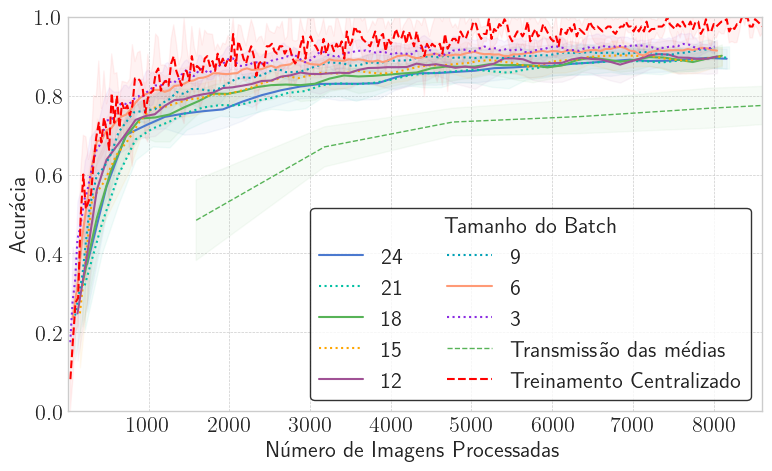

In [8]:
# Check if dfs list is populated and has data before plotting
if not dfs or all(df is None or df.empty for df in dfs):
    print("No dataframes available for plotting Accuracy.")
else:
    # Create a new figure and axes specifically for the Accuracy plot
    fig1, ax1 = plt.subplots(figsize=(8, 5)) # Adjust size as needed for single plot

    # --- Loop through each DataFrame and plot Accuracy on ax1 ---
    for i, df in enumerate(dfs):
        label = f'{batch_sizes[i]}' # Label for this experiment

        if df is None or df.empty or 'total_samples_processed' not in df.columns or 'accuracy' not in df.columns:
            print(f"Skipping plotting Accuracy for {label}: Missing data or required columns.")
            continue

        # Get the color and linestyle based on index
        line_color = colors[i % len(colors)]
        line_style = 'dotted' if i % 2 else '-'
        line_width = 1.5

        # Plot Mean Accuracy line
        ax1.plot(df['total_samples_processed'], df['accuracy'],
                 label=label, color=line_color, linewidth=line_width, linestyle=line_style)

        # Plot Accuracy CI band if calculated
        if 'accuracy_ci_lower' in df.columns and not df['accuracy_ci_lower'].isnull().all():
            ax1.fill_between(df['total_samples_processed'], df['accuracy_ci_lower'], df['accuracy_ci_upper'],
                             color=line_color, alpha=0.05)

    ax1.plot(df_avg['total_samples_processed'], df_avg['accuracy'],
             label="Transmissão das médias",
             color=colors[2], linestyle='dashed', linewidth=1.0)
    ax1.fill_between(df_avg['total_samples_processed'], df_avg['accuracy_ci_lower'], df_avg['accuracy_ci_upper'],
                     color=colors[2], alpha=0.05)

    ax1.plot(df_centralized['total_samples_processed'], df_centralized['accuracy'],
             label="Treinamento Centralizado",
             color='red', linestyle='dashed')
    ax1.fill_between(df_centralized['total_samples_processed'], df_centralized['accuracy_ci_lower'], df_centralized['accuracy_ci_upper'],
                     color='red', alpha=0.05)
    # --- Configure the Accuracy plot (ax1) ---
    ax1.set_xlabel('Número de Imagens Processadas')
    ax1.set_ylabel('Acurácia')

    # Configure and position Legend
    handles1, labels1 = ax1.get_legend_handles_labels()
    legend1 = ax1.legend(
        handles1,
        labels1,
        title="Tamanho do Batch",
        ncol=2, # Adjust number of columns if needed
        loc='lower right', # Adjust legend location as needed
        frameon=True,
        edgecolor='black',
        facecolor='white'
    )

    ax1.grid(True, which='both', linestyle='--', linewidth=0.5) # Grid style
    ax1.set_ylim(0, 1) # Ensure accuracy is between 0 and 1

    # Set x-axis limits using the overall min/max calculated in Cell 1
    if x_lim_lower is not None and x_lim_upper is not None:
         ax1.set_xlim(x_lim_lower, x_lim_upper)
    else:
         print("Warning: Overall x-axis limits not determined in Cell 1. Using default limits.")


    # --- Display the plot ---
    plt.tight_layout() # Adjust layout
    # Optional: Save the figure
    output_filename_acc = 'acuracia_imagens_processadas_ci.pdf'
    plt.gca().xaxis.set_major_locator(mpl.ticker.MaxNLocator(prune='lower'))
    plt.savefig(os.path.join('images', output_filename_acc), format='pdf', dpi=600)
    # print(f"Accuracy plot saved to images/{output_filename_acc}")
    plt.show()

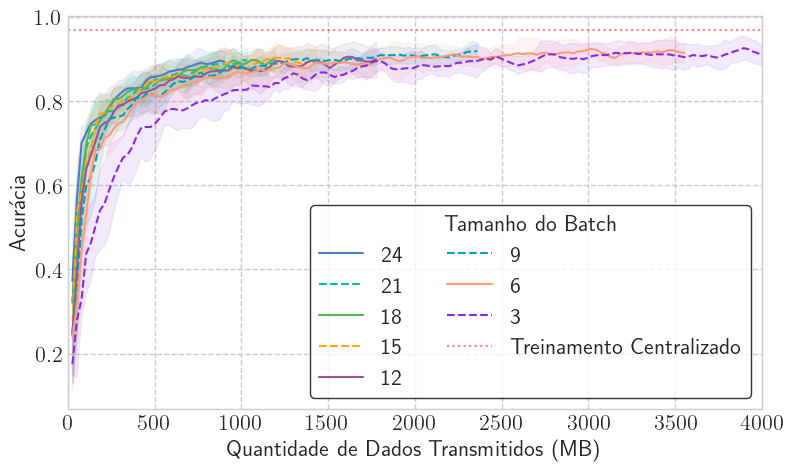

In [9]:
# Cell 3: Plot Loss vs. Total Samples Processed

# Check if dfs list is populated and has data before plotting
if not dfs or all(df is None or df.empty for df in dfs):
    print("No dataframes available for plotting Loss.")
else:
    # Create a new figure and axes specifically for the Loss plot
    fig2, ax2 = plt.subplots(figsize=(8, 5)) # Adjust size as needed

    # --- Loop through each DataFrame and plot Loss on ax2 ---
    for i, df in enumerate(dfs):
        label = f'{batch_sizes[i]}' # Label for this experiment

        if df is None or df.empty or 'total_samples_processed' not in df.columns or 'loss' not in df.columns:
            print(f"Skipping plotting Loss for {label}: Missing data or required columns.")
            continue

        # Get the color and linestyle based on index
        line_color = colors[i % len(colors)]
        line_style = 'dashed' if i % 2 else '-'
        line_width = 1.5

        # Plot Mean Loss line
        ax2.plot(df['total_bytes_transmitted'], df['accuracy'],
                 label=label, color=line_color, linewidth=line_width, linestyle=line_style)

        # Plot Loss CI band if calculated
        # Note: We are plotting the loss CI against total_samples_processed
        if 'accuracy_ci_lower' in df.columns and not df['accuracy_ci_lower'].isnull().all():
             ax2.fill_between(df['total_bytes_transmitted'], df['accuracy_ci_lower'], df['accuracy_ci_upper'],
                              color=line_color, alpha=0.1)


    # --- Configure the Loss plot (ax2) ---
    # Optional: Add a horizontal line for a baseline (like centralized training)
    # Adjust y-value, color, linestyle, and label as needed
    ax2.axhline(
        y=0.9687, # Example value - replace with your actual baseline if any
        color='red',
        linestyle='dotted',
        alpha=0.5,
        label='Treinamento Centralizado' # Example label
    )

    ax2.set_xlabel('Quantidade de Dados Transmitidos (MB)') # Match Accuracy plot x-label
    ax2.set_ylabel('Acurácia')


    # Configure and position Legend
    handles2, labels2 = ax2.get_legend_handles_labels()
    legend2 = ax2.legend(
         handles2,
         labels2,
         title="Tamanho do Batch",
         ncol=2,
         loc='lower right',
         frameon=True,
         edgecolor='black',
         facecolor='white'
    )

    ax2.grid(True, which='both', linestyle='--', linewidth=1) # Grid style

    # Set x-axis limits to match the Accuracy plot using the overall limits
    if x_lim_lower is not None and x_lim_upper is not None:
         ax2.set_xlim(x_lim_lower, x_lim_upper)
    else:
         print("Warning: Overall x-axis limits not determined in Cell 1. Using default limits.")

    # You might want to adjust the y-axis limits for loss based on your data
    # Find max loss across all dataframes if needed
    # all_loss_max = pd.concat([df['loss'] for df in dfs if df is not None and not df.empty and 'loss' in df.columns]).max()
    # ax2.set_ylim(0, all_loss_max * 1.1 if not pd.isna(all_loss_max) else None)


    # --- Display the plot ---
    plt.tight_layout() # Adjust layout
    plt.xlim(0, 4000)
    # Optional: Save the figure
    output_filename_loss = 'acuracia_dados_transmitidos_ci.pdf'
    plt.savefig(os.path.join('images', output_filename_loss), format='pdf', dpi=600)
    # print(f"Loss plot saved to images/{output_filename_loss}")

    plt.show()

In [10]:
for i, df in enumerate(dfs):
    print(f"Highest accuracy: {df['accuracy'].max()} for batch-size {batch_sizes[i]}")

Highest accuracy: 0.8954999923706055 for batch-size 24
Highest accuracy: 0.8965000033378601 for batch-size 21
Highest accuracy: 0.9010000109672548 for batch-size 18
Highest accuracy: 0.9020000100135804 for batch-size 15
Highest accuracy: 0.9050000071525574 for batch-size 12
Highest accuracy: 0.9185000061988832 for batch-size 9
Highest accuracy: 0.9235000014305116 for batch-size 6
Highest accuracy: 0.931000006198883 for batch-size 3


In [11]:
print(f"Highest accuracy Average Transmission: {df_avg['accuracy'].max()}.")

Highest accuracy Average Transmission: 0.9055000066757202.


In [12]:
df_avg.tail()

,round,loss,accuracy,images_seen_this_round,total_samples_processed,loss_std,accuracy_std,accuracy_sem,loss_sem,accuracy_ci_lower,accuracy_ci_upper,loss_ci_lower,loss_ci_upper
25,26,0.353123,0.8970,1590.0,41340.0,0.072689,0.022319,0.009981,0.032508,0.869288,0.924712,0.262868,0.443379
26,27,0.347889,0.9000,1590.0,42930.0,0.072278,0.022569,0.010093,0.032323,0.871976,0.928024,0.258144,0.437633
27,28,0.343174,0.9015,1590.0,44520.0,0.072081,0.022749,0.010173,0.032235,0.873254,0.929746,0.253674,0.432674
28,29,0.339057,0.9030,1590.0,46110.0,0.072140,0.024520,0.010966,0.032262,0.872554,0.933446,0.249484,0.428630
29,30,0.335267,0.9055,1590.0,47700.0,0.072141,0.021751,0.009728,0.032262,0.878492,0.932508,0.245692,0.424841


In [13]:
for i, df in enumerate(dfs):
    print(f"Total bytes transmitted: {df['total_bytes_transmitted'].max()} for batch-size {batch_sizes[i]}")

Total bytes transmitted: 901.0 for batch-size 24
Total bytes transmitted: 1033.5 for batch-size 21
Total bytes transmitted: 1192.5 for batch-size 18
Total bytes transmitted: 1431.0 for batch-size 15
Total bytes transmitted: 1775.5 for batch-size 12
Total bytes transmitted: 2358.5 for batch-size 9
Total bytes transmitted: 3551.0 for batch-size 6
Total bytes transmitted: 7075.5 for batch-size 3


In [35]:
df_random = pd.read_csv("./results/federated_kfold_size_2000_clients_10_rounds_50_batch_21_kfold_5_metrics.csv")
df_random

,round,total_samples_processed,accuracy,accuracy_std,loss,loss_std
0,1,205.8,0.31600,0.061507,2.155258,0.027567
1,2,386.4,0.43300,0.048264,2.001919,0.043118
2,3,562.8,0.56250,0.089320,1.838882,0.059702
3,4,726.6,0.60500,0.076506,1.693603,0.070611
4,5,915.6,0.64700,0.049320,1.556207,0.076759
5,6,1058.4,0.66100,0.039155,1.435983,0.085900
6,7,1247.4,0.65900,0.044672,1.335157,0.094186
7,8,1394.4,0.65700,0.064163,1.246528,0.098727
8,9,1566.6,0.68350,0.058806,1.153041,0.103881
9,10,1730.4,0.69700,0.058933,1.069548,0.106535


KeyError: 'accuracy_ci_lower'

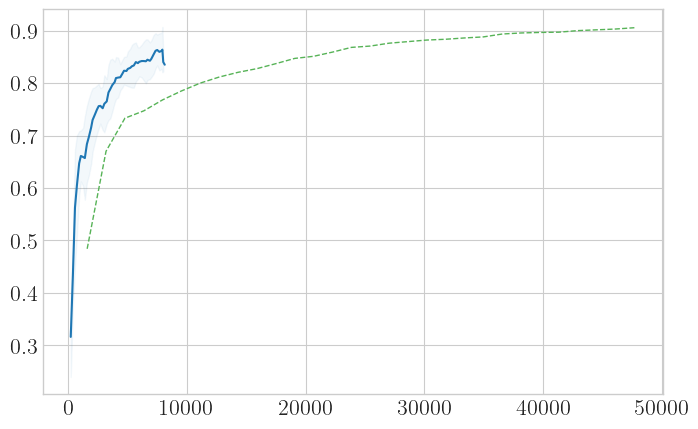

In [36]:
# --- Preprocess df_random just like others ---
if df_random is None or df_random.empty:
    print("df_random is empty. Cannot calculate CI bounds or plot.")
else:
    # Ensure SEM and CI columns exist
    if 'accuracy_std' not in df_random.columns or 'loss_std' not in df_random.columns:
        print("Warning: df_random is missing std columns. CI calculation skipped.")
        df_random['accuracy_ci_lower'] = np.nan
        df_random['accuracy_ci_upper'] = np.nan
        df_random['loss_ci_lower'] = np.nan
        df_random['loss_ci_upper'] = np.nan
    else:
        df_random['accuracy_sem'] = df_random['accuracy_std'] / np.sqrt(k_folds)
        df_random['loss_sem'] = df_random['loss_std'] / np.sqrt(k_folds)

        df_random['accuracy_ci_lower'] = df_random['accuracy'] - t_score * df_random['accuracy_sem']
        df_random['accuracy_ci_upper'] = df_random['accuracy'] + t_score * df_random['accuracy_sem']
        df_random['loss_ci_lower'] = df_random['loss'] - t_score * df_random['loss_sem']
        df_random['loss_ci_upper'] = df_random['loss'] + t_score * df_random['loss_sem']

    # --- Plot Accuracy with CI for df_random ---
    fig2, ax2 = plt.subplots(figsize=(8, 5))

    line_color = "#1f77b4"  # pick a consistent color (blue)

    ax2.plot(df_random['total_samples_processed'], df_random['accuracy'],
             label="Divisão Aleatória", color=line_color, linewidth=1.5, linestyle='-')

    if 'accuracy_ci_lower' in df_random.columns and not df_random['accuracy_ci_lower'].isnull().all():
        ax2.fill_between(df_random['total_samples_processed'],
                         df_random['accuracy_ci_lower'],
                         df_random['accuracy_ci_upper'],
                         color=line_color, alpha=0.05)

    # Compare with centralized & avg as before
    ax2.plot(df_avg['total_samples_processed'], df_avg['accuracy'],
             label="Transmissão das médias",
             color=colors[2], linestyle='dashed', linewidth=1.0)
    ax2.fill_between(df_avg['total_samples_processed'], df_avg['accuracy_ci_lower'], df_avg['accuracy_ci_upper'],
                     color=colors[2], alpha=0.05)

    ax2.plot(df_centralized['total_samples_processed'], df_centralized['accuracy'],
             label="Treinamento Centralizado",
             color='red', linestyle='dashed')
    ax2.fill_between(df_centralized['total_samples_processed'], df_centralized['accuracy_ci_lower'], df_centralized['accuracy_ci_upper'],
                     color='red', alpha=0.05)

    # --- Labels and legend ---
    ax2.set_xlabel('Número de Imagens Processadas')
    ax2.set_ylabel('Acurácia')
    ax2.legend(
        title="Experimentos",
        ncol=1,
        loc='lower right',
        frameon=True,
        edgecolor='black',
        facecolor='white'
    )
    ax2.grid(True, which='both', linestyle='--', linewidth=0.5)
    ax2.set_ylim(0, 1)

    # Use same x-axis limits as before if available
    if x_lim_lower is not None and x_lim_upper is not None:
        ax2.set_xlim(x_lim_lower, x_lim_upper)

    plt.tight_layout()
    output_filename_random_acc = 'acuracia_random_imagens_processadas_ci.pdf'
    plt.gca().xaxis.set_major_locator(mpl.ticker.MaxNLocator(prune='lower'))
    plt.savefig(os.path.join('images', output_filename_random_acc), format='pdf', dpi=600)
    plt.show()
